# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4590
      Test MAE: 4.75 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5580
      Test MAE: 11.45 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4582
      Test MAE: 18.27 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9941
      Test MAE: 1.99 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9559
      Test MAE: 15.68 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
  speed_ground_deviation     2.129483
condition_immunity_count     2.104291
     speed_fly_deviation     1.968049
      inflicts_petrified    -1.386249
     total_ability_count    -1.287835
      inflicts_paralyzed    -1.020474
  save_proficiency_count     0.821979
        has_spellcasting    -0.631444
             speed_climb    -0.595246
    movement_types_count     0.491472

CR2 Top Features by Coefficient:
                feature  coefficient
skill_proficiency_count    -4.606171
 save_proficiency_count     4.446243
            speed_climb    -4.064926
       inflicts_charmed    -3.201047
    vulnerability_count     3.177456
           speed_burrow    -2.964308
     inflicts_petrified    -2.735161
 size_ordinal_deviation     2.287912
    inflicts_frightened    -2.213589
            trait_count     1.841738

CR3 Top Features by Coefficient:
                 feature  coefficient
  save_proficiency_count    11.7455

## Investigate Specific Creatures

In [11]:
df[df['Name'].str.contains('Dragon')].head()

,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_poisoned,inflicts_blinded,inflicts_charmed,inflicts_deafened,inflicts_frightened,inflicts_incapacitated,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned
116,Brass Dragon Wyrmling,dragon,Medium,1,1.0,cr2,16 (3d8+3),49.5,16,21.845283,...,0,0,0,0,0,0,0,0,0,0
118,Copper Dragon Wyrmling,dragon,Medium,1,1.0,cr2,22 (4d8+4),49.5,22,22.673044,...,0,0,0,0,0,0,0,0,0,0
143,White Dragon Wyrmling,dragon,Medium,2,2.0,cr2,32 (5d8+10),54.0,32,32.309183,...,0,0,0,0,0,0,0,0,0,0
147,Black Dragon Wyrmling,dragon,Medium,2,2.0,cr2,33 (6d8+6),54.0,33,51.521121,...,0,0,0,0,0,0,0,0,0,0
148,Bronze Dragon Wyrmling,dragon,Medium,2,2.0,cr2,32 (5d8+10),54.0,32,46.646121,...,0,0,0,0,0,0,0,0,0,0


In [1]:
from notebooks.helper_files.feature_config import PHASE2_FEATURES


PHASE2_FEATURES

['ac_deviation',
 'attack_deviation',
 'dpr_deviation',
 'save_dc_deviation',
 'has_flying',
 'has_advantage_condition',
 'has_disadvantage_condition',
 'has_attackers_advantage',
 'inflicts_prone']

In [12]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
investigate_creature('Imp', df, contributions_df)

  IMP (CR 1.0)

Actual HP:              10
Predicted HP:            7
Error:                  -3  ( -30.4%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 1.0):                                50

PHASE 2: COMBAT STATS
  Feature: ac_deviation                   value:    1.0  hp impact:     -2
  Feature: attack_deviation               value:    0.0  hp impact:     -0
  Feature: dpr_deviation                  value:    4.0  hp impact:     -4
  Feature: save_dc_deviation              value:   -1.0  hp impact:      5
  Feature: has_flying                     value:    1.0  hp impact:     -4
  Feature: has_advantage_condition        value:    0.0  hp impact:     -0
  Feature: has_disadvantage_condition     value:    0.0  hp impact:      0
  Feature: has_attackers_advantage        value:    0.0  hp impact:      0
  Feature: inflicts_prone                 value:    0.0  hp impact:     -0
  ------------------------------

In [13]:
[c for c in contributions_df.columns if 'advant' in c]

['has_advantage_condition',
 'has_disadvantage_condition',
 'has_attackers_advantage',
 'phase2_advantage_contribution',
 'phase2_disadvantage_contribution',
 'phase2_attackers_advantage_contribution']

In [14]:
from notebooks.helper_files.parsers import has_advantage_condition


has_advantage_condition(df[df['Name'] == 'Cult Fanatic'])

0

In [15]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [16]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
  Cockatrice 0.500         27     27.000006 -0.000006
     Cultist 0.125          9      9.000076 -0.000076
       Camel 0.125         15     14.813485  0.186515
    Warhorse 0.500         19     19.201353 -0.201353
    Shrieker 0.000         13     13.412047 -0.412047
        Pony 0.125         11     10.580581  0.419419
Flying Sword 0.250         17     16.548376  0.451624
      Zombie 0.250         22     22.451675 -0.451675
      Kobold 0.125          5      5.503783 -0.503783
        Wolf 0.250         11     10.474136  0.525864

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
               Lemure 0.00         13      2.516665  10.483335
           Giant Wasp 0.50         13     24.088542 -11.088542
           Black Bear 0.50         19     30.276464 -11.276464
Giant Poisonous Snake 0.25         11     -0.410242  11.410242
            Crocodile 0.50  

In [21]:
# analysis_dfs['cr2']['actual_hp'].value_counts()

In [18]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
87,Ghost,undead,Medium,4,4.0,cr2,45 (10d8),100.8,45,45.357403,...,0,0,0,0,45,45.357403,4.0,-0.357403,0.357403,-0.794230
57,Rhinoceros,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,48.259740,...,0,0,0,0,45,48.259740,2.0,-3.259740,3.259740,-7.243867
13,Giant Hyena,beast,Large,1,1.0,cr2,45 (6d10+12),49.5,45,49.556868,...,0,0,0,0,45,49.556868,1.0,-4.556868,4.556868,-10.126373
52,Merrow,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,52.792361,...,0,0,0,0,45,52.792361,2.0,-7.792361,7.792361,-17.316357
47,Ochre Jelly,ooze,Large,2,2.0,cr2,45 (6d10+12),54.0,45,36.128802,...,0,0,0,0,45,36.128802,2.0,8.871198,8.871198,19.713772
74,Wight,undead,Medium,3,3.0,cr2,45 (6d8+18),78.0,45,35.744990,...,0,0,0,0,45,35.744990,3.0,9.255010,9.255010,20.566690
50,Hunter Shark,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,55.601826,...,0,0,0,0,45,55.601826,2.0,-10.601826,10.601826,-23.559614
66,Hell Hound,fiend,Medium,3,3.0,cr2,45 (7d8+14),78.0,45,56.499413,...,0,0,0,0,45,56.499413,3.0,-11.499413,11.499413,-25.554252
39,Silver Dragon Wyrmling,dragon,Medium,2,2.0,cr2,45 (6d8+18),54.0,45,29.889594,...,1,0,0,0,45,29.889594,2.0,15.110406,15.110406,33.578680
41,Centaur,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,27.774239,...,0,0,0,0,45,27.774239,2.0,17.225761,17.225761,38.279469



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


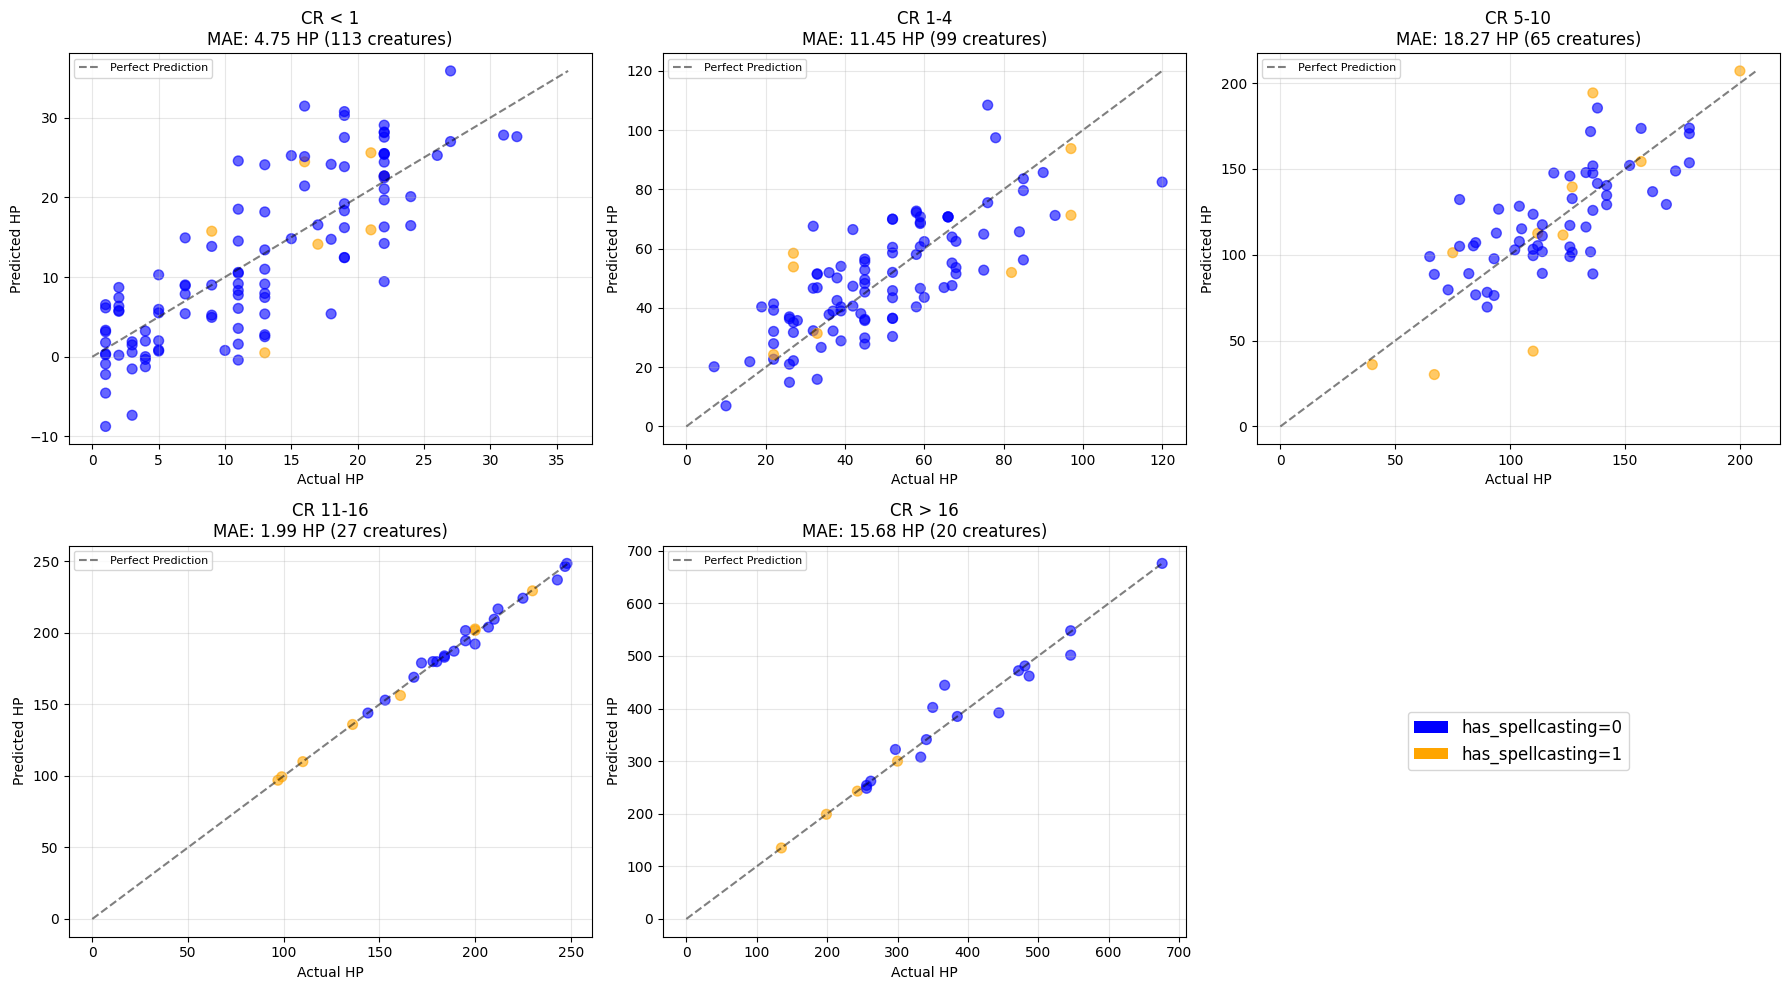

In [19]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_spellcasting')


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


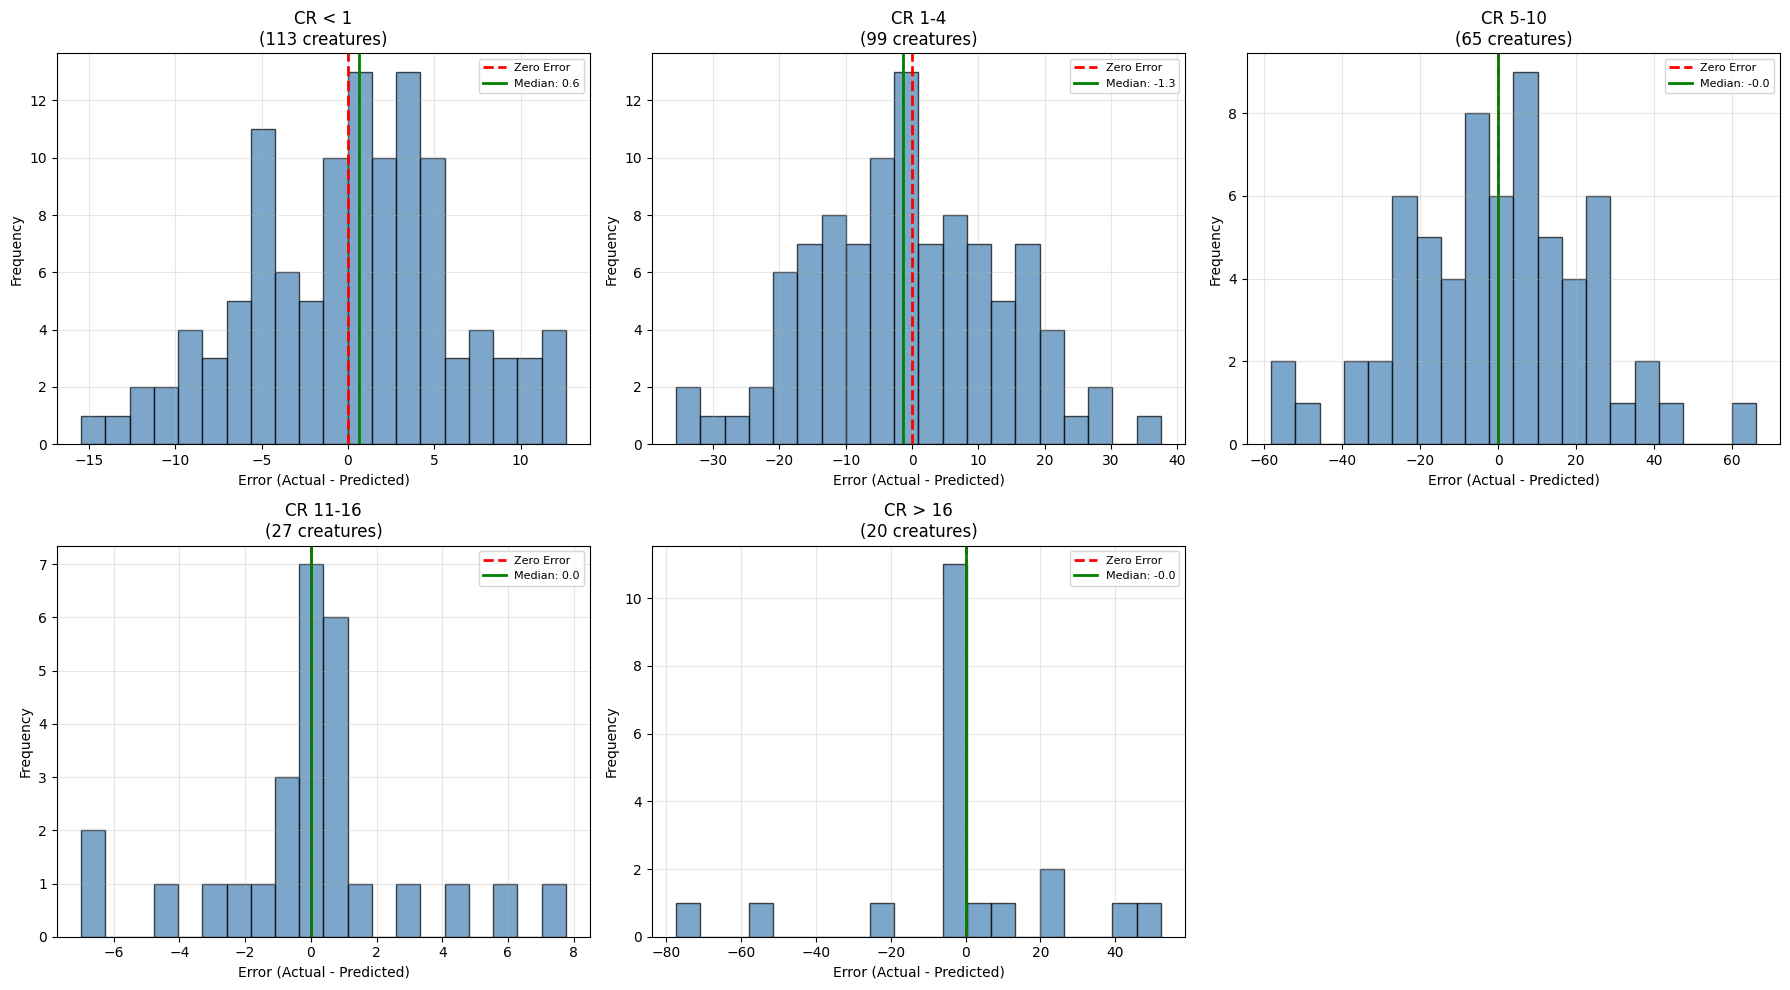

In [20]:
plot_error_hist(analysis_dfs)